# 04 — Prévision J+1 (baseline linéaire + LSTM)
Prédiction de la courbe de charge du lendemain à partir de 7 jours d'historique. Le notebook entraîne un modèle sur un client représentatif ; pour une évaluation finale, cette logique peut être rejouée sur plusieurs clients RS/RP.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {DEVICE}")

Device : cpu


## 4.1 Chargement & sélection d'un client représentatif

In [2]:
df_pivot = pd.read_parquet('../data/pivot.parquet')
features = pd.read_parquet('../data/features.parquet')

# Un client RP avec beaucoup de jours actifs (profil stable)
rp_ids = features[features['label'] == 'RP'].index
client_id = features.loc[rp_ids, 'nb_jours_actifs'].idxmax()
print(f"Client sélectionné : {client_id} (RP, {features.loc[client_id, 'nb_jours_actifs']:.0f} jours actifs)")

Client sélectionné : 1704875583 (RP, 364 jours actifs)


## 4.2 Préparation des séquences (fenêtre 7 jours → 1 jour)

In [3]:
# Matrice jours × 48 créneaux pour ce client
serie = df_pivot.loc[client_id].values  # shape (17520,)
N_SLOTS = 48

# Reshape en jours
n_days = len(serie) // N_SLOTS
matrix = serie[:n_days * N_SLOTS].reshape(n_days, N_SLOTS)  # (n_days, 48)
print(f"Jours disponibles : {n_days}")

# Normalisation par client
scaler_ts = MinMaxScaler()
matrix_norm = scaler_ts.fit_transform(matrix)

# Fenêtre glissante : 7 jours d'entrée → 1 jour de sortie
WINDOW = 7

X_seq, y_seq = [], []
for i in range(WINDOW, n_days):
    X_seq.append(matrix_norm[i-WINDOW:i])   # (7, 48)
    y_seq.append(matrix_norm[i])            # (48,)

X_seq = np.array(X_seq)   # (N, 7, 48)
y_seq = np.array(y_seq)   # (N, 48)
print(f"Séquences : X={X_seq.shape}  y={y_seq.shape}")

Jours disponibles : 364
Séquences : X=(357, 7, 48)  y=(357, 48)


## 4.3 Split train / test (80/20 chronologique)

In [4]:
split = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]
print(f"Train : {len(X_train)}  |  Test : {len(X_test)}")

Train : 285  |  Test : 72


## 4.4 Baseline — régression linéaire (J-1 et J-7)


In [5]:
# Features baseline : J-1, J-7 (même jour de la semaine)
X_bl_train = np.hstack([X_train[:, -1, :], X_train[:, -7, :]])  # (N, 96)
X_bl_test  = np.hstack([X_test[:, -1, :],  X_test[:, -7, :]])

lr = LinearRegression()
lr.fit(X_bl_train, y_train)
y_bl_pred = lr.predict(X_bl_test)

# Dénormalise
y_test_kw = scaler_ts.inverse_transform(y_test)
y_bl_kw   = scaler_ts.inverse_transform(y_bl_pred)

mae_bl  = mean_absolute_error(y_test_kw.flatten(), y_bl_kw.flatten())
rmse_bl = np.sqrt(mean_squared_error(y_test_kw.flatten(), y_bl_kw.flatten()))
print(f"Baseline (LR)  →  MAE: {mae_bl:.4f} kW  |  RMSE: {rmse_bl:.4f} kW")

Baseline (LR)  →  MAE: 0.2964 kW  |  RMSE: 0.4299 kW


## 4.5 Modèle LSTM

In [6]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=48, hidden_size=64, num_layers=2, output_size=48):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=0.2)
        self.fc   = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)        # (batch, seq, hidden)
        return self.fc(out[:, -1, :])  # dernière étape


class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):       return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader  = DataLoader(TimeSeriesDataset(X_test,  y_test),  batch_size=32)

model     = LSTMForecaster().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

print(model)

LSTMForecaster(
  (lstm): LSTM(48, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=48, bias=True)
)


## 4.6 Entraînement (50 epochs)

Epoch  10/50  train_loss=0.02375  val_loss=0.01354


Epoch  20/50  train_loss=0.01831  val_loss=0.01160


Epoch  30/50  train_loss=0.01634  val_loss=0.01081


Epoch  40/50  train_loss=0.01545  val_loss=0.01082


Epoch  50/50  train_loss=0.01433  val_loss=0.01116


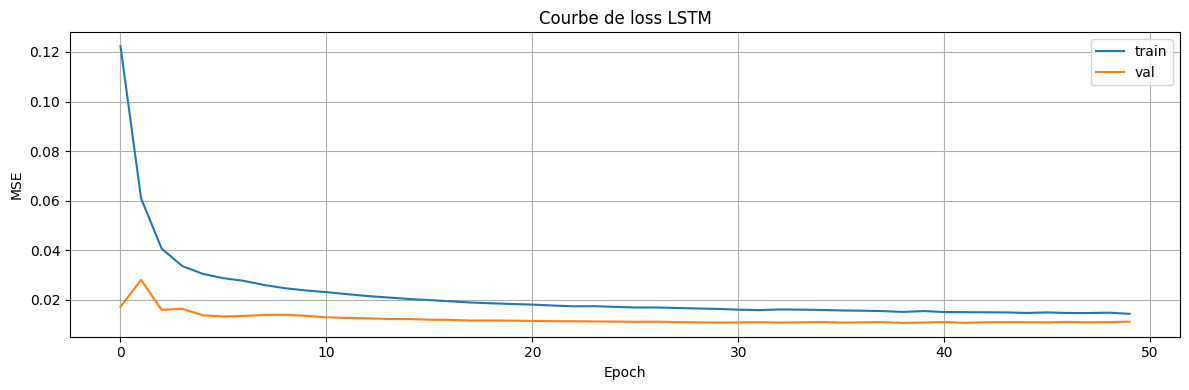

In [7]:
EPOCHS = 50
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    loss_ep = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        loss_ep += loss.item()
    train_losses.append(loss_ep / len(train_loader))

    model.eval()
    with torch.no_grad():
        val_loss = sum(criterion(model(xb.to(DEVICE)), yb.to(DEVICE)).item()
                       for xb, yb in test_loader) / len(test_loader)
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  train_loss={train_losses[-1]:.5f}  val_loss={val_losses[-1]:.5f}")

# Courbe de loss
plt.plot(train_losses, label='train')
plt.plot(val_losses,   label='val')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('Courbe de loss LSTM'); plt.legend()
plt.tight_layout(); plt.show()

## 4.7 Évaluation + visualisation

Baseline (LR)  →  MAE: 0.2964 kW  |  RMSE: 0.4299 kW
LSTM           →  MAE: 0.1908 kW  |  RMSE: 0.3045 kW


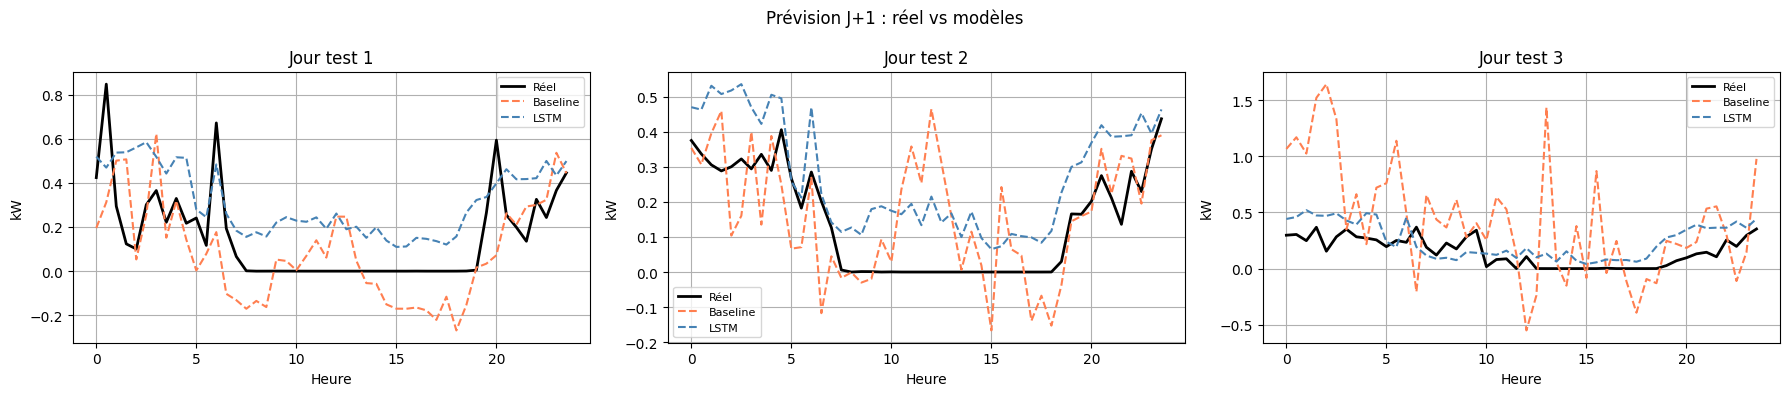

In [8]:
model.eval()
preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        preds.append(model(xb.to(DEVICE)).cpu().numpy())

y_lstm_norm = np.vstack(preds)
y_lstm_kw = scaler_ts.inverse_transform(y_lstm_norm)
mae_lstm  = mean_absolute_error(y_test_kw.flatten(), y_lstm_kw.flatten())
rmse_lstm = np.sqrt(mean_squared_error(y_test_kw.flatten(), y_lstm_kw.flatten()))

print(f"Baseline (LR)  →  MAE: {mae_bl:.4f} kW  |  RMSE: {rmse_bl:.4f} kW")
print(f"LSTM           →  MAE: {mae_lstm:.4f} kW  |  RMSE: {rmse_lstm:.4f} kW")

# Visualise les 3 premiers jours de test
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, ax in enumerate(axes):
    t = np.arange(N_SLOTS) * 0.5
    ax.plot(t, y_test_kw[i],   label='Réel',     color='black', linewidth=2)
    ax.plot(t, y_bl_kw[i],     label='Baseline', color='coral',     linestyle='--')
    ax.plot(t, y_lstm_kw[i],   label='LSTM',     color='steelblue', linestyle='--')
    ax.set_title(f'Jour test {i+1}')
    ax.set_xlabel('Heure'); ax.set_ylabel('kW')
    ax.legend(fontsize=8)

plt.suptitle('Prévision J+1 : réel vs modèles', fontsize=12)
plt.tight_layout(); plt.show()

## 4.8 Sauvegarde

In [9]:
torch.save(model.state_dict(), '../models/lstm_forecaster.pt')
joblib.dump(scaler_ts, '../models/scaler_ts.pkl')

import json
with open('../models/forecast_meta.json', 'w') as f:
    json.dump({
        'client_id': str(client_id),
        'label': str(features.loc[client_id, 'label']),
        'window_days': WINDOW,
        'mae': mae_lstm,
        'rmse': rmse_lstm,
        'mae_baseline': mae_bl,
        'rmse_baseline': rmse_bl,
        'evaluation_scope': 'single representative client; extend to a panel for final presentation',
    }, f, indent=2)

print(f"Sauvegardé : lstm_forecaster.pt, scaler_ts.pkl, forecast_meta.json")


Sauvegardé : lstm_forecaster.pt, scaler_ts.pkl, forecast_meta.json
